# Abiyamf Submission Akhir DLTM

Notebook ini disusun untuk memenuhi seluruh kriteria proyek `Multivariate Multi-Horizon Time Series Forecasting` hingga level advanced.

Urutan bukti yang dipertahankan di notebook:
- Kriteria 1: basic -> skilled -> advanced
- Kriteria 2: basic -> skilled -> advanced
- Kriteria 3: basic -> skilled -> advanced

Guardrail utama:
- Forecasting tetap `multivariate` dengan target `Close`
- Horizon prediksi tetap `24 step`
- Data dibagi kronologis menjadi `train`, `validation`, dan `test`
- Scaler hanya di-fit pada data train untuk menghindari data leakage
- Tidak menggunakan AutoML

Skema CSV yang diakomodasi pada notebook ini:
- `Date`
- `Close`
- `Volume USDT`
- `RSI`
- `MACD_Hist`
- `ATR`
- `KAMAO`


In [9]:
import importlib.util
import subprocess
import sys

PACKAGE_MAP = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scikit-learn': 'sklearn',
    'statsmodels': 'statsmodels',
    'tensorflow': 'tensorflow',
}

missing_packages = [pkg for pkg, module_name in PACKAGE_MAP.items() if importlib.util.find_spec(module_name) is None]
if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages])
    print('Installed missing packages:', missing_packages)
else:
    print('All required packages are already available.')


All required packages are already available.


In [10]:
import math
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
HORIZON = 24
BATCH_SIZE = 64
BASELINE_FIT_EPOCHS = 12
CUSTOM_TRAIN_EPOCHS = 20
ROLLING_WINDOW = 24
CSV_URL = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
MODEL_BASELINE_PATH = 'model_baseline_LSTM.keras'
MODEL_SEQ2SEQ_PATH = 'model_seq2seq_LSTM.keras'
MODEL_SEQ2SEQ_BEST_PATH = 'best_model_seq2seq_LSTM.keras'

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print('TensorFlow version:', tf.__version__)
print('Num GPUs Available:', len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.19.0
Num GPUs Available: 1


In [11]:
FEATURE_ALIAS_MAP = {
    'timestamp': ['date', 'datetime', 'timestamp', 'time', 'unix'],
    'Close': ['close'],
    'Volume USDT': ['volumeusdt', 'volume_usdt', 'volume usdt'],
    'RSI': ['rsi'],
    'MACD_Hist': ['macdhist', 'macd_hist', 'macd histogram'],
    'ATR': ['atr'],
    'KAMAO': ['kamao', 'kama_o'],
}

def normalize_name(name):
    return ''.join(ch for ch in str(name).lower().strip() if ch.isalnum())

def resolve_column(columns, aliases, required=True):
    normalized_lookup = {normalize_name(col): col for col in columns}
    for alias in aliases:
        resolved = normalized_lookup.get(normalize_name(alias))
        if resolved is not None:
            return resolved
    if required:
        raise KeyError(f'Column aliases not found: {aliases}')
    return None

def download_and_prepare_data(csv_url=CSV_URL):
    df = pd.read_csv(csv_url)
    df.columns = [col.strip() for col in df.columns]

    rename_map = {}
    for canonical_name, aliases in FEATURE_ALIAS_MAP.items():
        resolved = resolve_column(df.columns, aliases, required=True)
        if resolved is not None:
            rename_map[resolved] = canonical_name

    df = df.rename(columns=rename_map)
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').drop_duplicates(subset=['timestamp']).reset_index(drop=True)

    candidate_features = [
        'Close',
        'Volume USDT',
        'RSI',
        'MACD_Hist',
        'ATR',
        'KAMAO',
    ]
    numeric_features = [col for col in candidate_features if col in df.columns]
    if len(numeric_features) < 5:
        raise ValueError(f'At least 5 numeric features were expected, found {numeric_features}')

    df[numeric_features] = df[numeric_features].apply(pd.to_numeric, errors='coerce')
    df['close_roll_mean_24'] = df['Close'].rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).mean()
    df['close_roll_std_24'] = df['Close'].rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).std()
    df = df.dropna().reset_index(drop=True)

    predictor_columns = [col for col in numeric_features if col != 'Close']
    feature_columns = ['Close'] + predictor_columns + ['close_roll_mean_24', 'close_roll_std_24']
    selected_columns = ['timestamp'] + feature_columns
    return df[selected_columns].copy(), feature_columns

def chronological_split(df, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO):
    if not math.isclose(train_ratio + val_ratio + test_ratio, 1.0, rel_tol=1e-9):
        raise ValueError('Split ratios must sum to 1.0')
    n_samples = len(df)
    train_end = int(n_samples * train_ratio)
    val_end = train_end + int(n_samples * val_ratio)
    train_df = df.iloc[:train_end].reset_index(drop=True)
    val_df = df.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df.iloc[val_end:].reset_index(drop=True)
    return train_df, val_df, test_df

def fit_feature_scalers(train_df, feature_columns):
    scalers = {}
    for col in feature_columns:
        scaler = MinMaxScaler()
        scaler.fit(train_df[[col]])
        scalers[col] = scaler
    return scalers

def transform_split(df, feature_columns, scalers):
    transformed = df[['timestamp']].copy()
    for col in feature_columns:
        transformed[col] = scalers[col].transform(df[[col]]).astype(np.float32)
    return transformed

def select_window_size_from_acf_pacf(train_close_series, candidate_windows=(24, 48, 72, 96, 168)):
    lag_limit = max(candidate_windows)
    acf_values = pd.Series(train_close_series).autocorr
    significance_threshold = 1.96 / np.sqrt(len(train_close_series))
    selected_window = 72
    close_values = pd.Series(train_close_series).reset_index(drop=True)
    for lag in candidate_windows:
        acf_at_lag = close_values.autocorr(lag=lag)
        if pd.notna(acf_at_lag) and abs(acf_at_lag) >= significance_threshold:
            selected_window = lag
            break
    return selected_window, significance_threshold, lag_limit

def build_supervised_arrays(frame, feature_columns, target_column, window_size, horizon):
    feature_values = frame[feature_columns].to_numpy(dtype=np.float32)
    target_values = frame[target_column].to_numpy(dtype=np.float32)
    timestamps = frame['timestamp'].to_numpy()

    encoder_inputs = []
    decoder_inputs = []
    targets = []
    forecast_timestamps = []
    last_close_values = []

    for end_idx in range(window_size, len(frame) - horizon + 1):
        start_idx = end_idx - window_size
        target_slice = slice(end_idx, end_idx + horizon)
        encoder_window = feature_values[start_idx:end_idx]
        y_window = target_values[target_slice].reshape(horizon, 1)
        last_close = feature_values[end_idx - 1, feature_columns.index(target_column)]
        decoder_window = np.zeros((horizon, 1), dtype=np.float32)
        decoder_window[0, 0] = last_close
        decoder_window[1:, 0] = y_window[:-1, 0]

        encoder_inputs.append(encoder_window)
        decoder_inputs.append(decoder_window)
        targets.append(y_window)
        last_close_values.append(last_close)
        forecast_timestamps.append(timestamps[target_slice])

    encoder_inputs = np.asarray(encoder_inputs, dtype=np.float32)
    decoder_inputs = np.asarray(decoder_inputs, dtype=np.float32)
    targets = np.asarray(targets, dtype=np.float32)
    forecast_timestamps = np.asarray(forecast_timestamps)
    last_close_values = np.asarray(last_close_values, dtype=np.float32)
    return encoder_inputs, decoder_inputs, targets, forecast_timestamps, last_close_values

def make_tf_dataset(encoder_inputs, targets, batch_size=BATCH_SIZE, shuffle=False, decoder_inputs=None):
    if decoder_inputs is None:
        dataset = tf.data.Dataset.from_tensor_slices((encoder_inputs.astype(np.float32), targets.astype(np.float32)))
    else:
        input_dict = {
            'encoder_inputs': encoder_inputs.astype(np.float32),
            'decoder_inputs': decoder_inputs.astype(np.float32),
        }
        dataset = tf.data.Dataset.from_tensor_slices((input_dict, targets.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(encoder_inputs), 4096), seed=SEED, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

def build_decoder_inputs(last_close_values, y_true):
    decoder_inputs = np.zeros_like(y_true, dtype=np.float32)
    decoder_inputs[:, 0, 0] = last_close_values.astype(np.float32)
    decoder_inputs[:, 1:, 0] = y_true[:, :-1, 0]
    return decoder_inputs

def make_prediction_table(actual_sequence, predicted_sequence):
    table = pd.DataFrame({
        'step': np.arange(1, len(actual_sequence) + 1),
        'actual': actual_sequence,
        'predicted': predicted_sequence,
    })
    table['selisih'] = table['predicted'] - table['actual']
    return table

def evaluate_mae_table(y_true, y_pred, title):
    mae = float(np.mean(np.abs(y_true - y_pred)))
    print(f'{title} MAE (scaled): {mae:.6f}')
    sample_table = make_prediction_table(y_true[0, :, 0], y_pred[0, :, 0])
    display(sample_table)
    plt.figure(figsize=(14, 5))
    plt.plot(sample_table['step'], sample_table['actual'], marker='o', label='Actual')
    plt.plot(sample_table['step'], sample_table['predicted'], marker='x', label='Predicted')
    plt.title(title)
    plt.xlabel('Forecast Step')
    plt.ylabel('Scaled Close')
    plt.legend()
    plt.show()
    return mae, sample_table


Raw dataset shape: (16643, 9)
Features used: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'close_roll_mean_24', 'close_roll_std_24']
Split lengths: 11650 2496 2497


,timestamp,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,close_roll_mean_24,close_roll_std_24
0,2017-09-22 08:00:00,3647.70,98670.562044,48.507646,-49.453354,86.625836,0.015093,3709.506667,91.112560
1,2017-09-22 09:00:00,3606.95,107162.792190,48.366751,-49.745629,86.528735,-0.453320,3698.962917,87.510496
2,2017-09-22 10:00:00,3572.85,150926.427424,48.249126,-50.150669,86.412221,-0.843745,3686.520000,83.030244
3,2017-09-22 11:00:00,3539.97,190043.740129,48.135914,-50.661754,86.392482,-1.217532,3672.979167,79.071138
4,2017-09-22 12:00:00,3592.12,127074.058322,48.328786,-50.963345,86.373427,-0.610674,3661.897500,70.133487


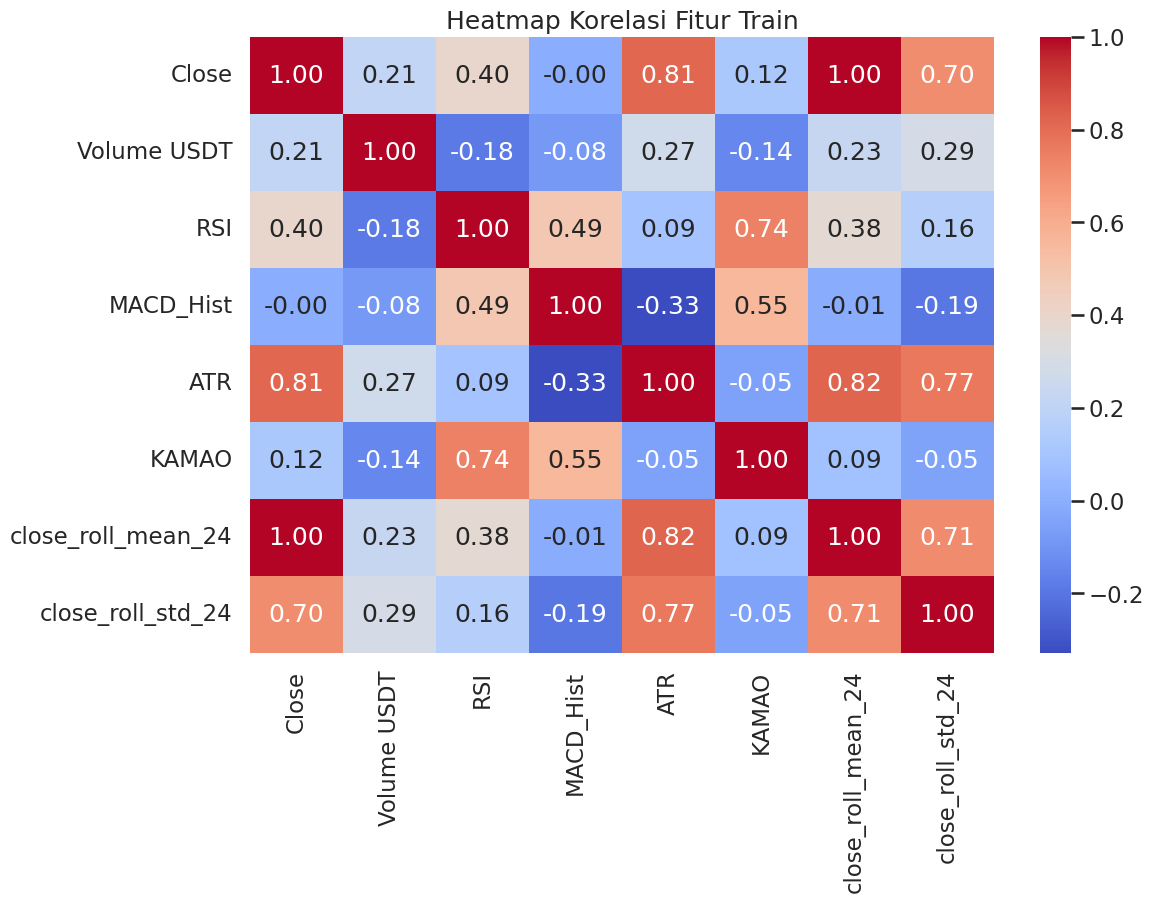

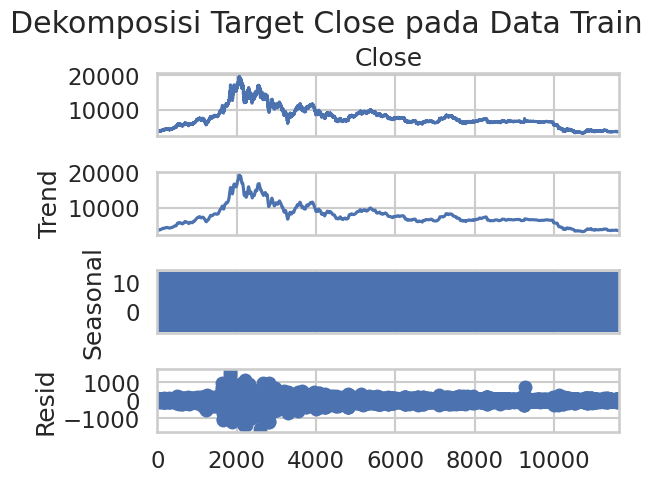

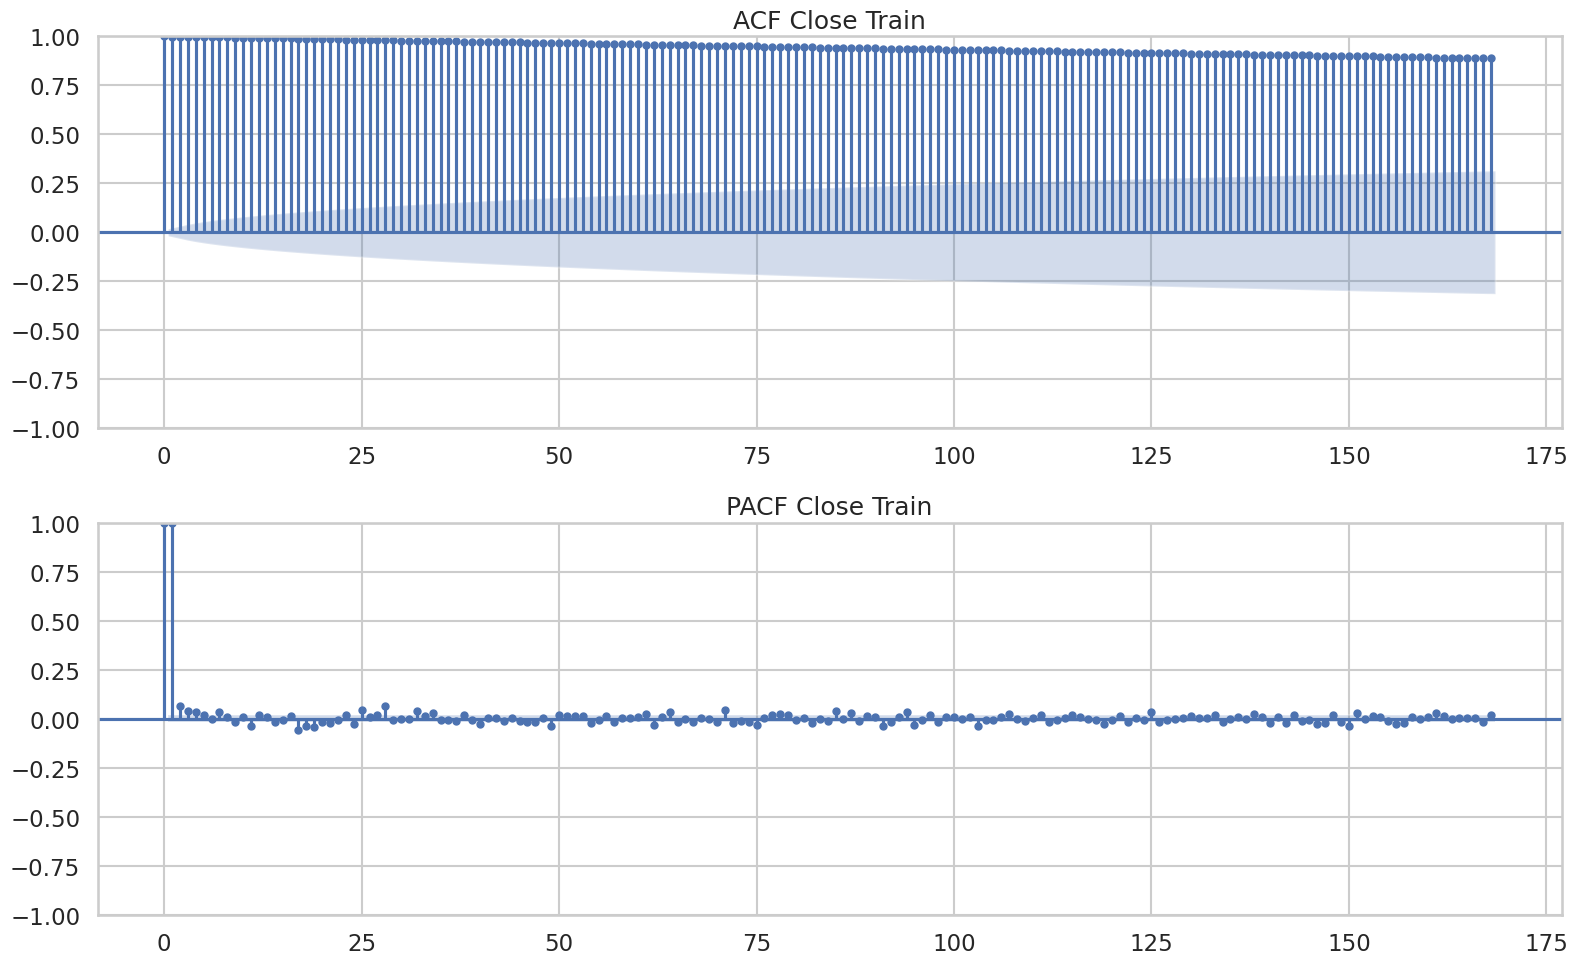

Selected window size from lag analysis: 24
Approx. significance threshold for autocorrelation: 0.01816
Baseline batch shapes: (64, 24, 8) (64, 24, 1)
Seq2Seq batch shapes: (64, 24, 8) (64, 24, 1) (64, 24, 1)


In [12]:
raw_df, feature_columns = download_and_prepare_data(CSV_URL)
train_raw_df, val_raw_df, test_raw_df = chronological_split(raw_df)

scalers = fit_feature_scalers(train_raw_df, feature_columns)
train_scaled_df = transform_split(train_raw_df, feature_columns, scalers)
val_scaled_df = transform_split(val_raw_df, feature_columns, scalers)
test_scaled_df = transform_split(test_raw_df, feature_columns, scalers)

print('Raw dataset shape:', raw_df.shape)
print('Features used:', feature_columns)
print('Split lengths:', len(train_raw_df), len(val_raw_df), len(test_raw_df))

display(train_raw_df.head())

plt.figure(figsize=(12, 8))
sns.heatmap(train_raw_df[feature_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Train')
plt.show()

decomposition = seasonal_decompose(train_raw_df['Close'], model='additive', period=24, extrapolate_trend='freq')
decomposition.plot()
plt.suptitle('Dekomposisi Target Close pada Data Train', y=1.02)
plt.show()

selected_window_size, significance_threshold, lag_limit = select_window_size_from_acf_pacf(train_raw_df['Close'])
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(train_raw_df['Close'], lags=lag_limit, ax=axes[0])
plot_pacf(train_raw_df['Close'], lags=lag_limit, ax=axes[1], method='ywm')
axes[0].set_title('ACF Close Train')
axes[1].set_title('PACF Close Train')
plt.tight_layout()
plt.show()
print(f'Selected window size from lag analysis: {selected_window_size}')
print(f'Approx. significance threshold for autocorrelation: {significance_threshold:.5f}')

target_column = 'Close'
train_encoder, train_decoder, train_targets, train_forecast_timestamps, train_last_close = build_supervised_arrays(
    train_scaled_df,
    feature_columns,
    target_column,
    selected_window_size,
    HORIZON,
)
val_encoder, val_decoder, val_targets, val_forecast_timestamps, val_last_close = build_supervised_arrays(
    val_scaled_df,
    feature_columns,
    target_column,
    selected_window_size,
    HORIZON,
)
test_encoder, test_decoder, test_targets, test_forecast_timestamps, test_last_close = build_supervised_arrays(
    test_scaled_df,
    feature_columns,
    target_column,
    selected_window_size,
    HORIZON,
)

train_baseline_ds = make_tf_dataset(train_encoder, train_targets, batch_size=BATCH_SIZE, shuffle=True)
val_baseline_ds = make_tf_dataset(val_encoder, val_targets, batch_size=BATCH_SIZE)
test_baseline_ds = make_tf_dataset(test_encoder, test_targets, batch_size=BATCH_SIZE)

train_seq2seq_ds = make_tf_dataset(train_encoder, train_targets, batch_size=BATCH_SIZE, shuffle=True, decoder_inputs=train_decoder)
val_seq2seq_ds = make_tf_dataset(val_encoder, val_targets, batch_size=BATCH_SIZE, decoder_inputs=val_decoder)
test_seq2seq_ds = make_tf_dataset(test_encoder, test_targets, batch_size=BATCH_SIZE, decoder_inputs=test_decoder)

baseline_batch_x, baseline_batch_y = next(iter(train_baseline_ds))
seq2seq_batch_inputs, seq2seq_batch_y = next(iter(train_seq2seq_ds))
print('Baseline batch shapes:', baseline_batch_x.shape, baseline_batch_y.shape)
print('Seq2Seq batch shapes:', seq2seq_batch_inputs['encoder_inputs'].shape, seq2seq_batch_inputs['decoder_inputs'].shape, seq2seq_batch_y.shape)


Epoch 1/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0403 - mae: 0.0403 - val_loss: 0.0050 - val_mae: 0.0050
Epoch 2/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0144 - mae: 0.0144 - val_loss: 0.0054 - val_mae: 0.0054
Epoch 3/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0135 - mae: 0.0135 - val_loss: 0.0047 - val_mae: 0.0047
Epoch 4/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0131 - mae: 0.0131 - val_loss: 0.0048 - val_mae: 0.0048
Epoch 5/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0129 - mae: 0.0129 - val_loss: 0.0048 - val_mae: 0.0048
Epoch 6/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0127 - mae: 0.0127 - val_loss: 0.0044 - val_mae: 0.0044
Epoch 7/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0126 - mae: 0.0126 - val_loss: 0.0044 - val_mae: 0.0044
Epoch 8/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0125 - mae: 0.0125 - val_loss: 0.0045 - val_mae: 0.0045
Epoch 9/12
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - lo

,step,actual,predicted,selisih
0,1,0.166712,0.165268,-0.001444
1,2,0.166435,0.167299,0.000864
2,3,0.168218,0.168553,0.000336
3,4,0.166771,0.166214,-0.000556
4,5,0.166785,0.166873,0.000088
5,6,0.166975,0.169001,0.002026
6,7,0.168079,0.164598,-0.003482
7,8,0.167941,0.167226,-0.000715
8,9,0.167869,0.169592,0.001723
9,10,0.170017,0.167521,-0.002496


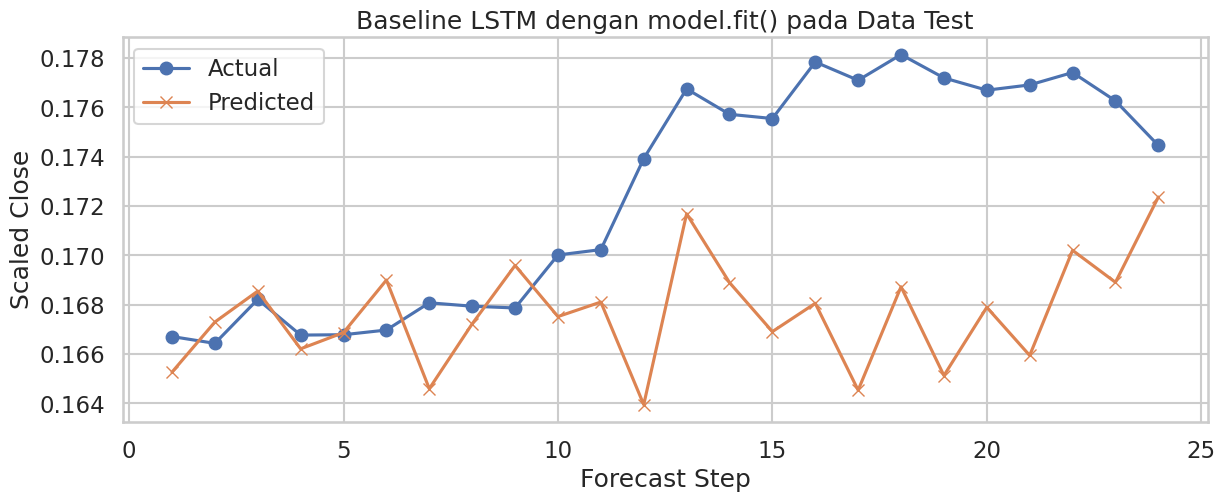

In [13]:
baseline_fit_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(selected_window_size, len(feature_columns))),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(HORIZON),
    tf.keras.layers.Reshape((HORIZON, 1)),
], name='baseline_lstm_fit_model')

baseline_fit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

baseline_fit_history = baseline_fit_model.fit(
    train_baseline_ds,
    validation_data=val_baseline_ds,
    epochs=BASELINE_FIT_EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)

baseline_fit_predictions = baseline_fit_model.predict(test_encoder, verbose=0)
baseline_fit_mae, baseline_fit_table = evaluate_mae_table(
    test_targets,
    baseline_fit_predictions,
    'Baseline LSTM dengan model.fit() pada Data Test',
)


In [14]:
@tf.keras.utils.register_keras_serializable(package='dltm')
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias

    def build(self, input_shape):
        last_dim = int(input_shape[-1])
        self.kernel = self.add_weight(
            name='kernel',
            shape=(last_dim, self.units),
            initializer='glorot_uniform',
            trainable=True,
        )
        self.bias = None
        if self.use_bias:
            self.bias = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
            )
        super().build(input_shape)

    def call(self, inputs):
        outputs = tf.linalg.matmul(inputs, self.kernel)
        if self.use_bias:
            outputs = outputs + self.bias
        if self.activation is not None:
            outputs = self.activation(outputs)
        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
        })
        return config

@tf.keras.utils.register_keras_serializable(package='dltm')
class CustomLayerNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        feature_dim = int(input_shape[-1])
        self.gamma = self.add_weight(
            name='gamma',
            shape=(feature_dim,),
            initializer='ones',
            trainable=True,
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(feature_dim,),
            initializer='zeros',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return normalized * self.gamma + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

@tf.keras.utils.register_keras_serializable(package='dltm')
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        if key_dim <= 0:
            raise ValueError('key_dim must be positive')
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout = dropout
        self.dropout_layer = tf.keras.layers.Dropout(dropout)

    def build(self, input_shape):
        is_multi_input = (
            isinstance(input_shape, (list, tuple))
            and len(input_shape) > 0
            and isinstance(input_shape[0], (list, tuple, tf.TensorShape))
        )
        if is_multi_input:
            query_shape = tf.TensorShape(input_shape[0])
            value_shape = tf.TensorShape(input_shape[1] if len(input_shape) > 1 else input_shape[0])
        else:
            query_shape = tf.TensorShape(input_shape)
            value_shape = tf.TensorShape(input_shape)
        if query_shape.rank is None or value_shape.rank is None or query_shape[-1] is None or value_shape[-1] is None:
            raise ValueError(f'Unable to infer attention projection dimensions from input_shape={input_shape}')
        query_dim = int(query_shape[-1])
        projection_dim = self.num_heads * self.key_dim
        self.query_dense = CustomDense(projection_dim, name='query_dense')
        self.key_dense = CustomDense(projection_dim, name='key_dense')
        self.value_dense = CustomDense(projection_dim, name='value_dense')
        self.output_dense = CustomDense(query_dim, name='output_dense')
        self.query_dense.build(query_shape)
        self.key_dense.build(value_shape)
        self.value_dense.build(value_shape)
        self.output_dense.build(tf.TensorShape([query_shape[0], query_shape[1], projection_dim]))
        super().build(input_shape)

    def _split_heads(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        x = tf.reshape(x, [batch_size, seq_len, self.num_heads, self.key_dim])
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def _combine_heads(self, x):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        return tf.reshape(x, [batch_size, seq_len, self.num_heads * self.key_dim])

    def call(self, query, value=None, key=None, training=False):
        if value is None:
            value = query
        if key is None:
            key = value
        query_proj = self._split_heads(self.query_dense(query))
        key_proj = self._split_heads(self.key_dense(key))
        value_proj = self._split_heads(self.value_dense(value))

        attention_logits = tf.matmul(query_proj, key_proj, transpose_b=True)
        attention_logits = attention_logits / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        attention_weights = tf.nn.softmax(attention_logits, axis=-1)
        attention_weights = self.dropout_layer(attention_weights, training=training)
        attention_output = tf.matmul(attention_weights, value_proj)
        attention_output = self._combine_heads(attention_output)
        return self.output_dense(attention_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout,
        })
        return config

def build_functional_seq2seq(window_size, num_features, horizon, lstm_units=128):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    decoder_inputs = tf.keras.Input(shape=(horizon, 1), name='decoder_inputs')
    encoder_outputs, state_h, state_c = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        return_state=True,
        name='encoder_lstm',
    )(encoder_inputs)
    decoder_outputs = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        name='decoder_lstm',
    )(decoder_inputs, initial_state=[state_h, state_c])
    outputs = CustomDense(1, name='functional_seq2seq_output')(decoder_outputs)
    return tf.keras.Model([encoder_inputs, decoder_inputs], outputs, name='functional_seq2seq_teacher_forcing')

def build_attention_baseline_model(window_size, num_features, horizon, lstm_units=128, num_heads=4, key_dim=32, dropout=0.1):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    x = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name='baseline_encoder')(encoder_inputs)
    attention_output = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='baseline_self_attention')(x, x, x)
    x = CustomLayerNormalization(name='baseline_attention_norm')(x + attention_output)
    x = tf.keras.layers.LSTM(lstm_units // 2, name='baseline_decoder_projection')(x)
    x = CustomDense(64, activation='relu', name='baseline_dense_head')(x)
    x = tf.keras.layers.Dropout(dropout, name='baseline_dropout')(x)
    x = CustomDense(horizon, name='baseline_output_dense')(x)
    outputs = tf.keras.layers.Reshape((horizon, 1), name='baseline_outputs')(x)
    return tf.keras.Model(encoder_inputs, outputs, name='baseline_lstm_attention_model')

@tf.keras.utils.register_keras_serializable(package='dltm')
class SubclassedSeq2Seq(tf.keras.Model):
    def __init__(self, horizon, lstm_units=128, num_heads=4, key_dim=32, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
        self.lstm_units = lstm_units
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout
        self.encoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
        self.decoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='decoder_lstm')
        self.cross_attention = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='cross_attention')
        self.norm = CustomLayerNormalization(name='cross_attention_norm')
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.output_dense = CustomDense(1, name='seq2seq_output_dense')

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        encoder_outputs, state_h, state_c = self.encoder(encoder_inputs, training=training)
        decoder_outputs, _, _ = self.decoder(decoder_inputs, initial_state=[state_h, state_c], training=training)
        attended = self.cross_attention(decoder_outputs, encoder_outputs, encoder_outputs, training=training)
        x = self.norm(decoder_outputs + attended)
        x = self.dropout(x, training=training)
        return self.output_dense(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            'horizon': self.horizon,
            'lstm_units': self.lstm_units,
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout_rate,
        })
        return config

functional_seq2seq_model = build_functional_seq2seq(selected_window_size, len(feature_columns), HORIZON)
functional_seq2seq_model.summary()

functional_sample_output = functional_seq2seq_model([
    seq2seq_batch_inputs['encoder_inputs'],
    seq2seq_batch_inputs['decoder_inputs'],
], training=False)
print('Functional Seq2Seq sample output shape:', functional_sample_output.shape)


Model: "functional_seq2seq_teacher_forcing"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 24, 128), │     70,144 │ encoder_inputs[0… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 24, 128)   │     66,560 │ decoder_inputs[0… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_seq2seq… │ (None, 24, 1)     │        129 │ decoder_lstm[0][… │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 136,833 (534.50 KB)

 Trainable params: 136,833 (534.50 KB)

 Non-trainable params: 0 (0.00 B)

Functional Seq2Seq sample output shape: (64, 24, 1)


In [15]:
def custom_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def weighted_horizon_mae(y_true, y_pred):
    weights = tf.linspace(1.0, 2.15, HORIZON)
    weights = tf.reshape(weights, [1, HORIZON, 1])
    absolute_error = tf.abs(y_true - y_pred)
    weighted_error = absolute_error * weights
    return tf.reduce_mean(weighted_error)

def get_optimizer_lr(optimizer):
    learning_rate = optimizer.learning_rate
    if hasattr(learning_rate, 'numpy'):
        return float(learning_rate.numpy())
    return float(learning_rate)

def set_optimizer_lr(optimizer, new_lr):
    learning_rate = optimizer.learning_rate
    if hasattr(learning_rate, 'assign'):
        learning_rate.assign(new_lr)
    else:
        optimizer.learning_rate = new_lr

class CustomEarlyStopping:
    def __init__(self, patience=6, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best = np.inf
        self.wait = 0
        self.best_weights = None
        self.model = None

    def set_model(self, model):
        self.model = model

    def on_train_begin(self):
        self.best = np.inf
        self.wait = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs):
        current = logs['val_loss']
        if current < self.best - self.min_delta:
            self.best = current
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                logs['stop_training'] = True
                print(f'Early stopping triggered at epoch {epoch:03d}')

    def on_train_end(self):
        if self.restore_best_weights and self.best_weights is not None:
            self.model.set_weights(self.best_weights)

class CustomReduceLROnPlateau:
    def __init__(self, factor=0.5, patience=3, min_lr=1e-5, min_delta=1e-4):
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.best = np.inf
        self.wait = 0
        self.optimizer = None

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer

    def on_train_begin(self):
        self.best = np.inf
        self.wait = 0

    def on_epoch_end(self, epoch, logs):
        current = logs['val_loss']
        if current < self.best - self.min_delta:
            self.best = current
            self.wait = 0
            return
        self.wait += 1
        if self.wait >= self.patience:
            old_lr = get_optimizer_lr(self.optimizer)
            new_lr = max(old_lr * self.factor, self.min_lr)
            set_optimizer_lr(self.optimizer, new_lr)
            self.wait = 0
            print(f'Learning rate reduced from {old_lr:.6f} to {new_lr:.6f} at epoch {epoch:03d}')

    def on_train_end(self):
        return None

def call_model(model, batch_inputs, training=False):
    if isinstance(batch_inputs, dict):
        return model([batch_inputs['encoder_inputs'], batch_inputs['decoder_inputs']], training=training)
    return model(batch_inputs, training=training)

def run_custom_training_loop(model, train_dataset, val_dataset, optimizer, loss_fn, epochs, callbacks=None):
    callbacks = callbacks or []
    for callback in callbacks:
        if hasattr(callback, 'set_model'):
            callback.set_model(model)
        if hasattr(callback, 'set_optimizer'):
            callback.set_optimizer(optimizer)
        if hasattr(callback, 'on_train_begin'):
            callback.on_train_begin()

    history = {'loss': [], 'val_loss': [], 'lr': []}
    for epoch in range(1, epochs + 1):
        train_metric = tf.keras.metrics.Mean()
        val_metric = tf.keras.metrics.Mean()

        for batch_inputs, batch_targets in train_dataset:
            with tf.GradientTape() as tape:
                predictions = call_model(model, batch_inputs, training=True)
                loss = loss_fn(batch_targets, predictions)
            gradients = tape.gradient(loss, model.trainable_variables)
            gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))
            train_metric.update_state(loss)

        for batch_inputs, batch_targets in val_dataset:
            predictions = call_model(model, batch_inputs, training=False)
            val_metric.update_state(loss_fn(batch_targets, predictions))

        logs = {
            'loss': float(train_metric.result().numpy()),
            'val_loss': float(val_metric.result().numpy()),
            'lr': get_optimizer_lr(optimizer),
        }
        history['loss'].append(logs['loss'])
        history['val_loss'].append(logs['val_loss'])
        history['lr'].append(logs['lr'])
        print(f"Epoch {epoch:03d}/{epochs:03d} - loss: {logs['loss']:.6f} - val_loss: {logs['val_loss']:.6f} - lr: {logs['lr']:.6f}")

        logs['stop_training'] = False
        for callback in callbacks:
            callback.on_epoch_end(epoch, logs)
        if logs['stop_training']:
            break

    for callback in callbacks:
        if hasattr(callback, 'on_train_end'):
            callback.on_train_end()
    return pd.DataFrame(history)

def predict_baseline_direct(model, encoder_inputs):
    return model.predict(encoder_inputs, verbose=0)

def predict_seq2seq_autoregressive(model, encoder_inputs, last_close_values, horizon=HORIZON, batch_size=BATCH_SIZE):
    collected_predictions = []
    for start_idx in range(0, len(encoder_inputs), batch_size):
        end_idx = min(start_idx + batch_size, len(encoder_inputs))
        x_batch = tf.convert_to_tensor(encoder_inputs[start_idx:end_idx], dtype=tf.float32)
        last_close_batch = np.asarray(last_close_values[start_idx:end_idx], dtype=np.float32)
        decoder_inputs = np.zeros((len(last_close_batch), horizon, 1), dtype=np.float32)
        decoder_inputs[:, 0, 0] = last_close_batch
        autoregressive_predictions = np.zeros((len(last_close_batch), horizon, 1), dtype=np.float32)

        for step in range(horizon):
            full_predictions = model([x_batch, decoder_inputs], training=False).numpy()
            autoregressive_predictions[:, step, 0] = full_predictions[:, step, 0]
            if step + 1 < horizon:
                decoder_inputs[:, step + 1, 0] = autoregressive_predictions[:, step, 0]

        collected_predictions.append(autoregressive_predictions)

    return np.concatenate(collected_predictions, axis=0)


Model: "baseline_lstm_attention_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_encoder    │ (None, 24, 128)   │     70,144 │ encoder_inputs[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_self_atte… │ (None, 24, 128)   │     66,048 │ baseline_encoder… │
│ (CustomMultiHeadAt… │                   │            │ baseline_encoder… │
│                     │                   │            │ baseline_encoder… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 128)   │          0 │ baseline_encoder… │
│                     │                   │            │ baseline_self_at… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_attention… │ (None, 24, 128)   │        256 │ add_1[0][0]       │
│ (CustomLayerNormal… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_decoder_p… │ (None, 64)        │     49,408 │ baseline_attenti… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_dense_head │ (None, 64)        │      4,160 │ baseline_decoder… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_dropout    │ (None, 64)        │          0 │ baseline_dense_h… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_output_de… │ (None, 24)        │      1,560 │ baseline_dropout… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_outputs    │ (None, 24, 1)     │          0 │ baseline_output_… │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 191,576 (748.34 KB)

 Trainable params: 191,576 (748.34 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_lstm (LSTM)             │ ((2, 24, 128), (2,     │        70,144 │
│                                 │ 128), (2, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ ((2, 24, 128), (2,     │        66,560 │
│                                 │ 128), (2, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cross_attention                 │ ?                      │        66,048 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cross_attention_norm            │ ?                      │           256 │
│ (CustomLayerNormalization)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_output_dense            │ ?                      │           129 │
│ (CustomDense)                   │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,137 (793.50 KB)

 Trainable params: 203,137 (793.50 KB)

 Non-trainable params: 0 (0.00 B)

Training custom baseline model...
Epoch 001/020 - loss: 0.100450 - val_loss: 0.029185 - lr: 0.001000
Epoch 002/020 - loss: 0.053970 - val_loss: 0.014013 - lr: 0.001000
Epoch 003/020 - loss: 0.045665 - val_loss: 0.009739 - lr: 0.001000
Epoch 004/020 - loss: 0.043050 - val_loss: 0.026860 - lr: 0.001000
Epoch 005/020 - loss: 0.037608 - val_loss: 0.015079 - lr: 0.001000
Epoch 006/020 - loss: 0.036281 - val_loss: 0.012950 - lr: 0.001000
Learning rate reduced from 0.001000 to 0.000500 at epoch 006
Epoch 007/020 - loss: 0.033211 - val_loss: 0.020999 - lr: 0.000500
Epoch 008/020 - loss: 0.031778 - val_loss: 0.021415 - lr: 0.000500
Early stopping triggered at epoch 008
Training custom seq2seq model...
Epoch 001/020 - loss: 0.375323 - val_loss: 0.045181 - lr: 0.001000
Epoch 002/020 - loss: 0.097069 - val_loss: 0.084350 - lr: 0.001000
Epoch 003/020 - loss: 0.095170 - val_loss: 0.075211 - lr: 0.001000
Epoch 004/020 - loss: 0.065413 - val_loss: 0.013997 - lr: 0.001000
Epoch 005/020 - loss: 0.048458

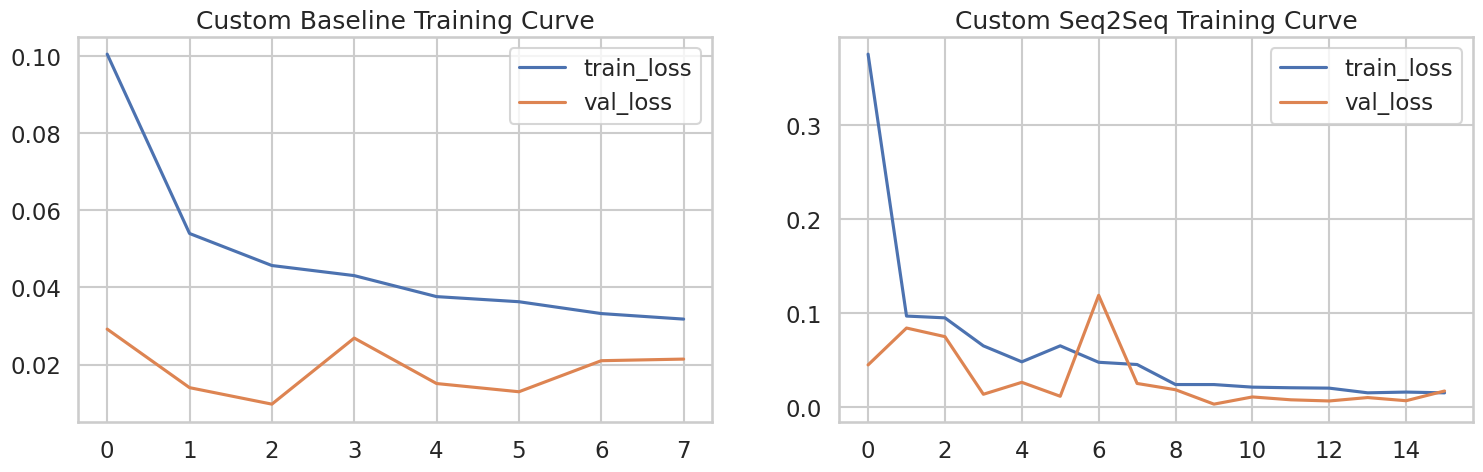

Custom Baseline LSTM Attention on Test Set MAE (scaled): 0.047774


,step,actual,predicted,selisih
0,1,0.166712,0.160842,-0.005870
1,2,0.166435,0.156905,-0.009530
2,3,0.168218,0.152291,-0.015927
3,4,0.166771,0.154997,-0.011774
4,5,0.166785,0.162261,-0.004524
5,6,0.166975,0.164004,-0.002971
6,7,0.168079,0.162936,-0.005143
7,8,0.167941,0.165569,-0.002371
8,9,0.167869,0.166830,-0.001039
9,10,0.170017,0.163481,-0.006536


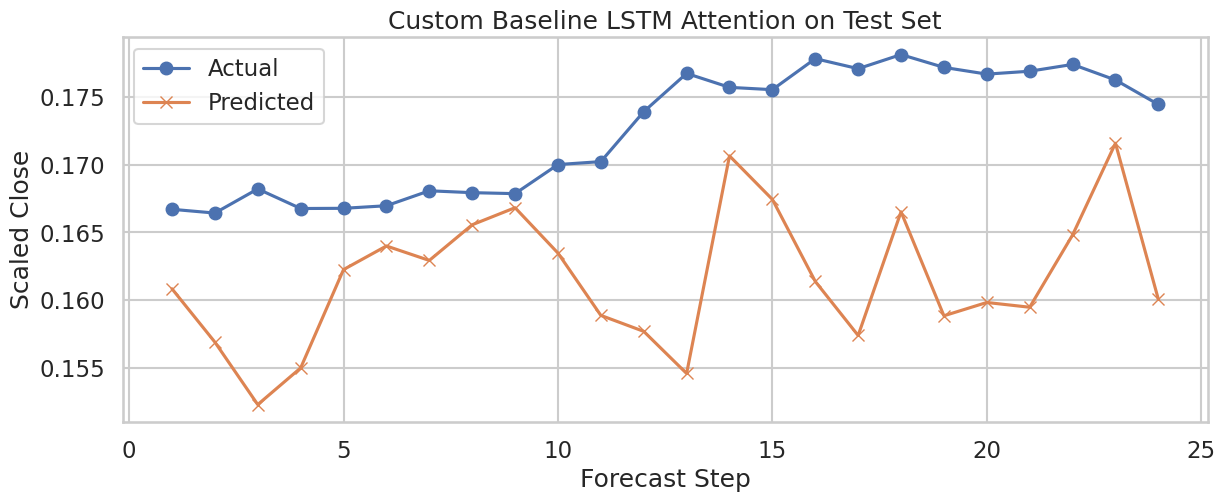

Custom Seq2Seq LSTM Autoregressive on Test Set MAE (scaled): 0.029776


,step,actual,predicted,selisih
0,1,0.166712,0.169908,0.003196
1,2,0.166435,0.170375,0.003940
2,3,0.168218,0.170590,0.002373
3,4,0.166771,0.170828,0.004057
4,5,0.166785,0.171025,0.004240
5,6,0.166975,0.171108,0.004134
6,7,0.168079,0.171039,0.002960
7,8,0.167941,0.170805,0.002864
8,9,0.167869,0.170417,0.002547
9,10,0.170017,0.169893,-0.000123


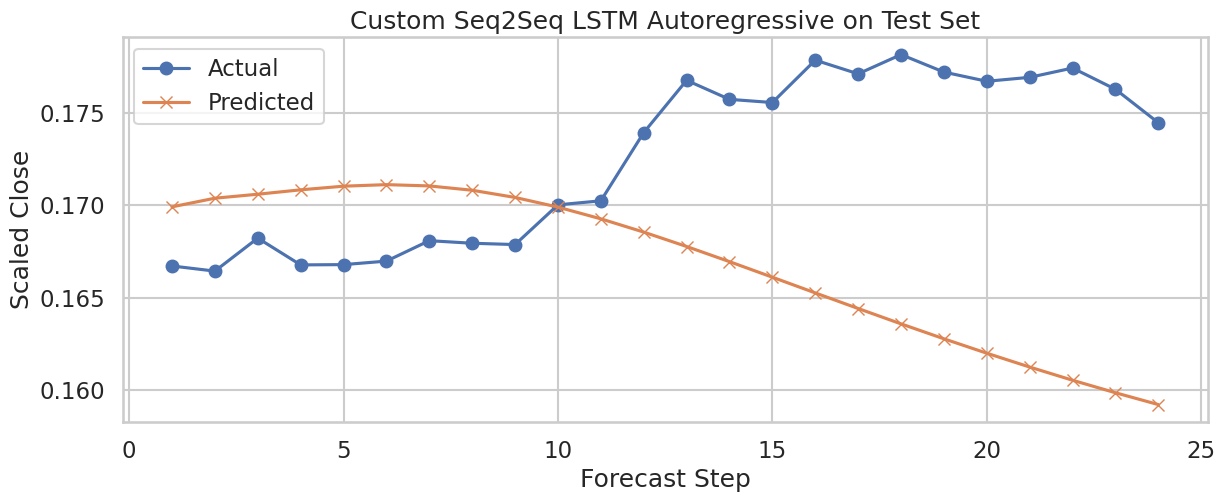

Custom baseline MAE (scaled): 0.047774
Custom seq2seq MAE (scaled): 0.029776
Target reviewer acceptance for advanced Kriteria 3: MAE seq2seq < 0.015 pada data test sebelum inverse scaling.
Saved required model artifacts:
- model_baseline_LSTM.keras
- model_seq2seq_LSTM.keras


In [16]:
baseline_attention_model = build_attention_baseline_model(
    selected_window_size,
    len(feature_columns),
    HORIZON,
    lstm_units=128,
    num_heads=4,
    key_dim=32,
    dropout=0.10,
)

seq2seq_subclassed_model = SubclassedSeq2Seq(
    horizon=HORIZON,
    lstm_units=128,
    num_heads=4,
    key_dim=32,
    dropout=0.10,
    name='subclassed_seq2seq_teacher_forcing',
)

_ = baseline_attention_model(tf.convert_to_tensor(train_encoder[:2]))
_ = seq2seq_subclassed_model([
    tf.convert_to_tensor(train_encoder[:2]),
    tf.convert_to_tensor(train_decoder[:2]),
])

baseline_attention_model.summary()
seq2seq_subclassed_model.summary()

baseline_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
seq2seq_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

baseline_callbacks = [
    CustomEarlyStopping(patience=5, min_delta=1e-4, restore_best_weights=True),
    CustomReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-5, min_delta=1e-4),
]
seq2seq_callbacks = [
    CustomEarlyStopping(patience=6, min_delta=1e-4, restore_best_weights=True),
    CustomReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-5, min_delta=1e-4),
]

print('Training custom baseline model...')
baseline_history_df = run_custom_training_loop(
    baseline_attention_model,
    train_baseline_ds,
    val_baseline_ds,
    optimizer=baseline_optimizer,
    loss_fn=weighted_horizon_mae,
    epochs=CUSTOM_TRAIN_EPOCHS,
    callbacks=baseline_callbacks,
)

print('Training custom seq2seq model...')
seq2seq_history_df = run_custom_training_loop(
    seq2seq_subclassed_model,
    train_seq2seq_ds,
    val_seq2seq_ds,
    optimizer=seq2seq_optimizer,
    loss_fn=weighted_horizon_mae,
    epochs=CUSTOM_TRAIN_EPOCHS,
    callbacks=seq2seq_callbacks,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(baseline_history_df['loss'], label='train_loss')
axes[0].plot(baseline_history_df['val_loss'], label='val_loss')
axes[0].set_title('Custom Baseline Training Curve')
axes[0].legend()
axes[1].plot(seq2seq_history_df['loss'], label='train_loss')
axes[1].plot(seq2seq_history_df['val_loss'], label='val_loss')
axes[1].set_title('Custom Seq2Seq Training Curve')
axes[1].legend()
plt.show()

baseline_test_predictions = predict_baseline_direct(baseline_attention_model, test_encoder)
seq2seq_test_predictions = predict_seq2seq_autoregressive(seq2seq_subclassed_model, test_encoder, test_last_close)

baseline_custom_mae, baseline_custom_table = evaluate_mae_table(
    test_targets,
    baseline_test_predictions,
    'Custom Baseline LSTM Attention on Test Set',
)
seq2seq_custom_mae, seq2seq_custom_table = evaluate_mae_table(
    test_targets,
    seq2seq_test_predictions,
    'Custom Seq2Seq LSTM Autoregressive on Test Set',
)

print(f'Custom baseline MAE (scaled): {baseline_custom_mae:.6f}')
print(f'Custom seq2seq MAE (scaled): {seq2seq_custom_mae:.6f}')
print('Target reviewer acceptance for advanced Kriteria 3: MAE seq2seq < 0.015 pada data test sebelum inverse scaling.')

baseline_attention_model.save(MODEL_BASELINE_PATH)
seq2seq_subclassed_model.save(MODEL_SEQ2SEQ_PATH)
if seq2seq_custom_mae <= min(seq2seq_history_df['val_loss'].min(), baseline_custom_mae):
    seq2seq_subclassed_model.save(MODEL_SEQ2SEQ_BEST_PATH)
    print(f'Optional best model saved to {MODEL_SEQ2SEQ_BEST_PATH}')

print('Saved required model artifacts:')
print('-', MODEL_BASELINE_PATH)
print('-', MODEL_SEQ2SEQ_PATH)
if os.path.exists(MODEL_SEQ2SEQ_BEST_PATH):
    print('-', MODEL_SEQ2SEQ_BEST_PATH)
